In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import numpy as np
from skbio.diversity import beta_diversity
from skbio.diversity import alpha_diversity
from skbio.stats.ordination import pcoa
from skbio.stats.distance import anosim

/home/huayuqin/miniconda3/envs/soil/lib/python3.11/site-packages/numpy/core/getlimits.py:542: UserWarning: Signature b'\x00\xd0\xcc\xcc\xcc\xcc\xcc\xcc\xfb\xbf\x00\x00\x00\x00\x00\x00' for <class 'numpy.longdouble'> does not match any known type: falling back to type probe function.
This warnings indicates broken support for the dtype!
  machar = _get_machar(dtype)


In [2]:
otu_tab = pd.read_csv('../pre-calculated_data/all_otu_table.S3.5.rib_prot_S2_rpsB.ebd', sep='\t', index_col=0)
otu_tab

,AAAAAAAACGCGAACCGCTACGCCCGCAAGGTCGGATTTACGTCGGTGGCGTTGATCGAC,AAAAAGAACGCCATCAGCGAAGCTCAAAAGCTGGGCGTCGCGACGGTCGCATTGATCGAC,AAAAAGAACGCCATCAGCGAATCTCAAAAGCTGGGCGTCGCGACGGTCGCATTGATCGAC,AAAAAGAACGCCGTGAAAGAAGCCCGCAAGCTGGGCATCGCCACGGTGGCGCTCATCGAC,AAAAAGATAGCCAACAAAGAAGCGCACCGGCTCAAAAAAAACGTCGCGGCAATCGTCCAA,AAAAATATTGCATTGAAAGAAGCGCAGAGATTAAACGTAAACACTTTTGGAATTGTTGAT,AAAAATGGGGCGCTCGCGGAAGCGAAGCGACTCGGCATTCCGATCGTTGGCATCGTCGAT,AAACAAAATGCGGTCAACGAGGCGCGACGTCTTGGCATTCCAGTCGTCGCGATCGTCGAT,AAACACAACGCCGTTGCTGAGGCGCGTCGGCTCAAAATCCCGGTCGTCGCGATAGTGGAT,AAACACAACGCGGTGAAGGAAGCCCGCCGCCTGTCGATCCCGGTCATCGCCATGCTCGAC,...,TGCGCAGTTCGTATCGACGACTGCAACGACAGGAATACCGAGCTTCTTGGCTTCGTGAAT,TGGAGAATCTGTGTCACAGAGAGCAATAACGGGAATGTTGACGTAGCTGGCCTCCTTGAT,TGGCACCTGGCGGTCGAGGAGGCCCGCAAGCTGCGGATCCCGATCATCGGCATCCTCGAC,TGTGAAAATGTTTCAGATGAATTTGCTTCAGCTAACATTCCAACTATAGGAATTGTTGAC,TTCAGAGAAGTTGTATCTGAAGCTTATGATATGGAGATTCCAGTTGTTGCGGCAATGGAT,TTGAAGATCTCGATAATGGTTGGCCGGGCACTCCGCATAAAAACAGTCTCGATGATCGAC,TTGAATATCGCATTCACAGAAGCAATACGGCTGGGTATGGGTACTTTCGGGATGGTGGAG,TTGCGCATCGCGGTCAGCGAGGCGAACAAGCTGGGCATCCCGATCGTCGCTATGGTGGAC,TTTGCTGCAGCGATAAAAGAGGCTTCATCCTTGAGTATTCCATCGTTAGGATTGATGGAT,TTTTATTCGTGTTTTTTTGAATCGACTTATTGTGGAATTCCGGCTATTGGTATGATTGAT
CPSNJ01_350,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CPSNJ02_350,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CPSNJ03_350,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CPSNJ04_350,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CPSNJ08_350,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CPSNJ09_350,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CPSNJ10_350,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CPSNJ11_350,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CPSNJ13_350,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CPSNJ14_350,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
metadata = pd.read_csv('../pre-calculated_data/metadata_otu.csv', index_col='Sample')
metadata.loc[metadata['Site'].str.startswith('NanJing'), 'Site'] = 'NanJing'
metadata.loc[metadata['Site'].str.startswith('ShangHai'), 'Site'] = 'ShangHai'
metadata

,Site
Sample,
CPSNJ01_350,NanJing
CPSNJ02_350,NanJing
CPSNJ03_350,NanJing
CPSNJ04_350,NanJing
CPSNJ08_350,NanJing
CPSNJ09_350,NanJing
CPSNJ10_350,NanJing
CPSNJ11_350,NanJing
CPSNJ13_350,NanJing


In [5]:
#remove samples (<100 total count OTUs)
otus_filt = otu_tab[otu_tab.sum(axis=1) >= 100]
otus_filt_wo0 = otus_filt[otus_filt.sum(axis=1) > 0]
otus_filt_wo0 = otus_filt_wo0.loc[:,otus_filt_wo0.sum(axis=0) > 0]

otus_filt_wo0['Sum'] = otus_filt_wo0.sum(axis=1)
otus_RA = otus_filt_wo0.iloc[:, :].div(otus_filt_wo0.Sum, axis=0)
otus_RA = otus_RA.drop(['Sum'], axis=1)

#remove low RA
otus_RA = otus_RA.T
otus_RA['Mean'] = otus_RA.mean(axis=1)
otus_RA_filt = otus_RA.loc[otus_RA['Mean'].between(0.00001, 1)]
otus_RA_filt = otus_RA_filt.drop(['Mean'], axis=1)
otus_RA_filt 

,CPSNJ01_350,CPSNJ02_350,CPSNJ03_350,CPSNJ04_350,CPSNJ08_350,CPSNJ09_350,CPSNJ10_350,CPSNJ11_350,CPSNJ13_350,CPSNJ14_350,...,SNJ08_350,SNJ09_350,SNJ10_350,SNJ11_350,SNJ13_350,SNJ14_350,SNJ15_350,SNJ16_350,SNJ19_350,SNJ20_350
AAAAAGAACGCCATCAGCGAAGCTCAAAAGCTGGGCGTCGCGACGGTCGCATTGATCGAC,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.00000
AAACAAAATGCGGTCAACGAGGCGCGACGTCTTGGCATTCCAGTCGTCGCGATCGTCGAT,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000809,0.0,...,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.00000
AACCACACCCTGCTGCACGAGTGCGGCCTCGCCTCCATCCCAACCATCGGCGTCATCGAC,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.00000
AACCAGATTGCCATCAAGGAGGCCACCAAGTTCCACATCCCCACCATCGGCATCACAGAC,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.00000
AACTACACCCTCTTGTATGAGTGTGCATTAGCTACCATCCCCACCATTGGCGTCATTGAC,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.00000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GTTGCTGTTGGTATCGACAACGCCGATGACCGGAATACCCAGCTTGTTGGCTTCCTGGAT,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.00000
GTTGGCGTTCGTATCCACAATGCCCATCACAGGGATGCGCAGTGTGTTGGCTTCTTTGAC,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.00000
TACCACGCTGCCGTCCGCGAGGCGGTGCGTGCTGGCGTGCCCATCATCGCGTTTGCAAAC,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.00000
TGAACAGTTGGTGTCAACGACGGCAACGATGGGGATATCAAGCCTGTTGGCTTCTTTGAT,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.000258,0.0,0.0,0.000782,0.0,0.0,0.0,0.0,0.0,0.00019


In [6]:
otus_RA_filt_zoom = otus_RA_filt * 1000000
np.set_printoptions(precision=5)
otus_np = otus_RA_filt_zoom.to_numpy()

minval = np.min(otus_np[np.nonzero(otus_np)])
pseudo = minval/2
otus_RA_filt_zoom.replace([0],pseudo, inplace=True)

otus_RA_filt_zoom = otus_RA_filt_zoom.T
otus_RA_filt_zoom

,AAAAAGAACGCCATCAGCGAAGCTCAAAAGCTGGGCGTCGCGACGGTCGCATTGATCGAC,AAACAAAATGCGGTCAACGAGGCGCGACGTCTTGGCATTCCAGTCGTCGCGATCGTCGAT,AACCACACCCTGCTGCACGAGTGCGGCCTCGCCTCCATCCCAACCATCGGCGTCATCGAC,AACCAGATTGCCATCAAGGAGGCCACCAAGTTCCACATCCCCACCATCGGCATCACAGAC,AACTACACCCTCTTGTATGAGTGTGCATTAGCTACCATCCCCACCATTGGCGTCATTGAC,AATTATATAATATGTAATGAGGCTATATCTATGTTTTTGCCTATTATTGCAATAGTTGAC,AATTATATAGTTTTAAAAGAAGCCGCTTTAATGTTTATGCCTGTTATAGGTATTATTGAT,ACACATCCAGCAGTCGTCGATTCGGCTAAACTCCTGATCCCGACCGTCGGTATTGTTGAC,AGAACAATTTGTGTCGACGACTGCAACGATGGGGATGCCCAGACGATTAGCTTCAGCGAC,AGCGCCAACGCCGTGCGCGAAGCCCGTAAAATGCGCTTGCCAATCGTAGCCGTTGTCGAC,...,GTCGGCGTTGGTGTCCACGATGCCAACGATGGGGATGCCGAGACGGTTGGCTTCCTTGAC,GTGAAGAACGCCGCGAAGCAGGCCGCCGACGCCGGCATCCCCATCGTCTCCATCGAGGGC,GTTAGCGTTAGTGTCAACGAGACCAACAACAGGCACACCAAGTGTCTTTGCTTCCTTAAC,GTTGCAGTTGGTATCGACGAGTGCAACGATCGGGATATTGAGCAGGTTTGCTTCGTGGAC,GTTGCAGTTGGTATCGACGATGGCCACGGTGGTAATGCCCAGCTTGTTTGCTTCGTGAAC,GTTGCTGTTGGTATCGACAACGCCGATGACCGGAATACCCAGCTTGTTGGCTTCCTGGAT,GTTGGCGTTCGTATCCACAATGCCCATCACAGGGATGCGCAGTGTGTTGGCTTCTTTGAC,TACCACGCTGCCGTCCGCGAGGCGGTGCGTGCTGGCGTGCCCATCATCGCGTTTGCAAAC,TGAACAGTTGGTGTCAACGACGGCAACGATGGGGATATCAAGCCTGTTGGCTTCTTTGAT,TGAACAGTTTGTATCGACCACTGCAAAAACCGGAATGCCGAGCTTGTTGGCTTCAGCGAC
CPSNJ01_350,85.587128,85.587128,85.587128,85.587128,85.587128,886.328385,85.587128,85.587128,221.582096,85.587128,...,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128
CPSNJ02_350,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,...,85.587128,85.587128,85.587128,85.587128,501.253133,85.587128,85.587128,85.587128,85.587128,85.587128
CPSNJ03_350,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,...,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128
CPSNJ04_350,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,...,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128
CPSNJ08_350,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,...,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128
CPSNJ09_350,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,...,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128
CPSNJ10_350,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,...,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128
CPSNJ11_350,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,...,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128
CPSNJ13_350,85.587128,808.843354,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,...,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128
CPSNJ14_350,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,...,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128


In [7]:
np.set_printoptions(precision=5)
otus_rows = otus_RA_filt_zoom.index.tolist()
otus_cols = otus_RA_filt_zoom.columns.tolist()
otus_np = otus_RA_filt_zoom.to_numpy()

log_otus_tab = np.log10(otus_np)
otus_tab_F = pd.DataFrame(log_otus_tab, columns=otus_cols, index=otus_rows)
otus_tab_F

,AAAAAGAACGCCATCAGCGAAGCTCAAAAGCTGGGCGTCGCGACGGTCGCATTGATCGAC,AAACAAAATGCGGTCAACGAGGCGCGACGTCTTGGCATTCCAGTCGTCGCGATCGTCGAT,AACCACACCCTGCTGCACGAGTGCGGCCTCGCCTCCATCCCAACCATCGGCGTCATCGAC,AACCAGATTGCCATCAAGGAGGCCACCAAGTTCCACATCCCCACCATCGGCATCACAGAC,AACTACACCCTCTTGTATGAGTGTGCATTAGCTACCATCCCCACCATTGGCGTCATTGAC,AATTATATAATATGTAATGAGGCTATATCTATGTTTTTGCCTATTATTGCAATAGTTGAC,AATTATATAGTTTTAAAAGAAGCCGCTTTAATGTTTATGCCTGTTATAGGTATTATTGAT,ACACATCCAGCAGTCGTCGATTCGGCTAAACTCCTGATCCCGACCGTCGGTATTGTTGAC,AGAACAATTTGTGTCGACGACTGCAACGATGGGGATGCCCAGACGATTAGCTTCAGCGAC,AGCGCCAACGCCGTGCGCGAAGCCCGTAAAATGCGCTTGCCAATCGTAGCCGTTGTCGAC,...,GTCGGCGTTGGTGTCCACGATGCCAACGATGGGGATGCCGAGACGGTTGGCTTCCTTGAC,GTGAAGAACGCCGCGAAGCAGGCCGCCGACGCCGGCATCCCCATCGTCTCCATCGAGGGC,GTTAGCGTTAGTGTCAACGAGACCAACAACAGGCACACCAAGTGTCTTTGCTTCCTTAAC,GTTGCAGTTGGTATCGACGAGTGCAACGATCGGGATATTGAGCAGGTTTGCTTCGTGGAC,GTTGCAGTTGGTATCGACGATGGCCACGGTGGTAATGCCCAGCTTGTTTGCTTCGTGAAC,GTTGCTGTTGGTATCGACAACGCCGATGACCGGAATACCCAGCTTGTTGGCTTCCTGGAT,GTTGGCGTTCGTATCCACAATGCCCATCACAGGGATGCGCAGTGTGTTGGCTTCTTTGAC,TACCACGCTGCCGTCCGCGAGGCGGTGCGTGCTGGCGTGCCCATCATCGCGTTTGCAAAC,TGAACAGTTGGTGTCAACGACGGCAACGATGGGGATATCAAGCCTGTTGGCTTCTTTGAT,TGAACAGTTTGTATCGACCACTGCAAAAACCGGAATGCCGAGCTTGTTGGCTTCAGCGAC
CPSNJ01_350,1.932408,1.932408,1.932408,1.932408,1.932408,2.947595,1.932408,1.932408,2.345535,1.932408,...,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408
CPSNJ02_350,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,...,1.932408,1.932408,1.932408,1.932408,2.700057,1.932408,1.932408,1.932408,1.932408,1.932408
CPSNJ03_350,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,...,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408
CPSNJ04_350,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,...,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408
CPSNJ08_350,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,...,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408
CPSNJ09_350,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,...,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408
CPSNJ10_350,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,...,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408
CPSNJ11_350,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,...,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408
CPSNJ13_350,1.932408,2.907864,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,...,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408
CPSNJ14_350,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,...,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408


In [8]:
bc_div = beta_diversity('canberra', log_otus_tab, ids=otus_rows, validate=True)
bc_pcoa = pcoa(bc_div)

In [9]:
df = bc_pcoa.samples
pc1_cpsnj1 = df.loc[['CPSNJ01_350','CPSNJ02_350','CPSNJ03_350','CPSNJ04_350']]['PC1']
pc2_cpsnj1 = df.loc[['CPSNJ01_350','CPSNJ02_350','CPSNJ03_350','CPSNJ04_350']]['PC2']
pc1_cpsnj2 = df.loc[['CPSNJ08_350','CPSNJ09_350','CPSNJ10_350','CPSNJ11_350','CPSNJ13_350','CPSNJ14_350','CPSNJ15_350','CPSNJ16_350','CPSNJ19_350','CPSNJ20_350']]['PC1']
pc2_cpsnj2 = df.loc[['CPSNJ08_350','CPSNJ09_350','CPSNJ10_350','CPSNJ11_350','CPSNJ13_350','CPSNJ14_350','CPSNJ15_350','CPSNJ16_350','CPSNJ19_350','CPSNJ20_350']]['PC2']
pc1_snj1 = df.loc[['SNJ01_350','SNJ02_350','SNJ03_350','SNJ04_350']]['PC1']
pc2_snj1 = df.loc[['SNJ01_350','SNJ02_350','SNJ03_350','SNJ04_350']]['PC2']
pc2_snj2 = df.loc[['SNJ08_350','SNJ09_350','SNJ10_350','SNJ11_350','SNJ13_350','SNJ14_350','SNJ15_350','SNJ16_350','SNJ19_350','SNJ20_350']]['PC2']
pc1_snj2 = df.loc[['SNJ08_350','SNJ09_350','SNJ10_350','SNJ11_350','SNJ13_350','SNJ14_350','SNJ15_350','SNJ16_350','SNJ19_350','SNJ20_350']]['PC1']
pc1_fd5 = df.loc[['1_350','2_350','3_350','4_350','5_350']]['PC1']
pc2_fd5 = df.loc[['1_350','2_350','3_350','4_350','5_350']]['PC2']
pc1_fd7 = df.loc[['6_350','7_350','8_350','9_350']]['PC1']
pc2_fd7 = df.loc[['6_350','7_350','8_350','9_350']]['PC2']
pc1_gq = df.loc[['10_350','11_350','12_350','13_350','14_350','15_350','16_350','17_350','18_350']]['PC1']
pc2_gq = df.loc[['10_350','11_350','12_350','13_350','14_350','15_350','16_350','17_350','18_350']]['PC2']
pc1_sj = df.loc[['23_350','24_350','25_350','26_350','27_350','28_350','29_350','30_350']]['PC1']
pc2_sj = df.loc[['23_350','24_350','25_350','26_350','27_350','28_350','29_350','30_350']]['PC2']
pc1_hx = df.loc[['19_350','20_350','21_350','22_350']]['PC1']
pc2_hx = df.loc[['19_350','20_350','21_350','22_350']]['PC2']
bc_pcoa.proportion_explained

PC1     0.119568
PC2     0.061517
PC3     0.042745
PC4     0.037809
PC5     0.033372
PC6     0.025544
PC7     0.024867
PC8     0.023506
PC9     0.021209
PC10    0.020142
PC11    0.019967
PC12    0.018680
PC13    0.018326
PC14    0.017812
PC15    0.017006
PC16    0.016779
PC17    0.016266
PC18    0.015979
PC19    0.015817
PC20    0.015328
PC21    0.014980
PC22    0.014712
PC23    0.014502
PC24    0.014330
PC25    0.013951
PC26    0.013697
PC27    0.013447
PC28    0.013248
PC29    0.013146
PC30    0.013141
PC31    0.012981
PC32    0.012670
PC33    0.012496
PC34    0.012182
PC35    0.012136
PC36    0.012021
PC37    0.011870
PC38    0.011527
PC39    0.011410
PC40    0.011138
PC41    0.011060
PC42    0.010866
PC43    0.010569
PC44    0.010339
PC45    0.010049
PC46    0.009882
PC47    0.009463
PC48    0.009336
PC49    0.009101
PC50    0.009080
PC51    0.008855
PC52    0.008689
PC53    0.008579
PC54    0.008271
PC55    0.008158
PC56    0.008014
PC57    0.007864
PC58    0.000000
dtype: float64

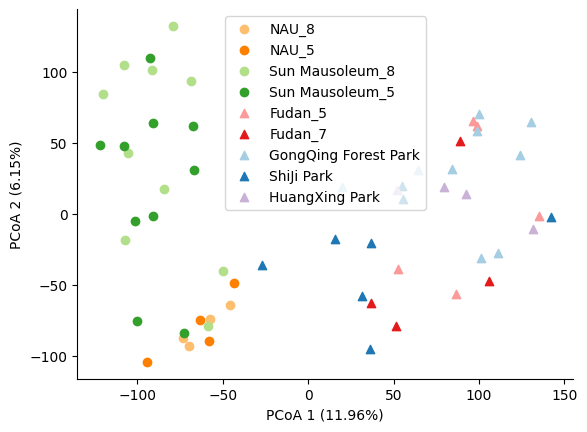

In [10]:
fig, ax = plt.subplots()
ax.scatter(pc1_cpsnj1, pc2_cpsnj1,c='#fdbf6f', label='NAU_8')
ax.scatter(pc1_snj1, pc2_snj1,c='#ff7f00', label='NAU_5')
ax.scatter(pc1_cpsnj2, pc2_cpsnj2,c='#b2df8a', label='Sun Mausoleum_8')
ax.scatter(pc1_snj2, pc2_snj2,c='#33a02c', label='Sun Mausoleum_5')
ax.scatter(pc1_fd5, pc2_fd5,c='#fb9a99',marker='^', label='Fudan_5')
ax.scatter(pc1_fd7, pc2_fd7,c='#e31a1c',marker='^', label='Fudan_7')
ax.scatter(pc1_gq, pc2_gq,c='#a6cee3',marker='^', label='GongQing Forest Park')
ax.scatter(pc1_sj, pc2_sj,c='#1f78b4',marker='^', label='ShiJi Park')
ax.scatter(pc1_hx, pc2_hx,c='#cab2d6',marker='^', label='HuangXing Park')
plt.legend()
ax.set_xlabel('PCoA 1 (11.96%)')
ax.set_ylabel('PCoA 2 (6.15%)')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

In [11]:
bc_div = beta_diversity('braycurtis', log_otus_tab, ids=otus_rows, validate=True)
bc_pcoa = pcoa(bc_div)

In [12]:
pcoa_df = bc_pcoa.samples[['PC1', 'PC2']]
pcoa_df

,PC1,PC2
CPSNJ01_350,-0.004314,-0.005722
CPSNJ02_350,-0.002780,-0.003868
CPSNJ03_350,-0.004493,-0.005533
CPSNJ04_350,-0.003488,-0.004524
CPSNJ08_350,-0.006388,-0.001261
CPSNJ09_350,-0.005871,0.006503
CPSNJ10_350,-0.006704,0.006526
CPSNJ11_350,-0.007517,0.005246
CPSNJ13_350,-0.004402,0.005969
CPSNJ14_350,-0.004929,0.008013


In [13]:
p = pd.read_csv(r'../pre-calculated_data/sample_P.csv',index_col='Sample_id')
p

,P
Sample_id,
1_350,0.890
2_350,1.044
3_350,1.041
4_350,0.776
5_350,1.352
6_350,1.157
7_350,1.065
8_350,0.828
9_350,1.050


In [14]:
plot_data = pcoa_df.join(p[['P']])
plot_data

,PC1,PC2,P
CPSNJ01_350,-0.004314,-0.005722,1.507
CPSNJ02_350,-0.002780,-0.003868,0.918
CPSNJ03_350,-0.004493,-0.005533,1.108
CPSNJ04_350,-0.003488,-0.004524,1.261
CPSNJ08_350,-0.006388,-0.001261,1.098
CPSNJ09_350,-0.005871,0.006503,1.223
CPSNJ10_350,-0.006704,0.006526,1.164
CPSNJ11_350,-0.007517,0.005246,1.666
CPSNJ13_350,-0.004402,0.005969,1.561
CPSNJ14_350,-0.004929,0.008013,1.464


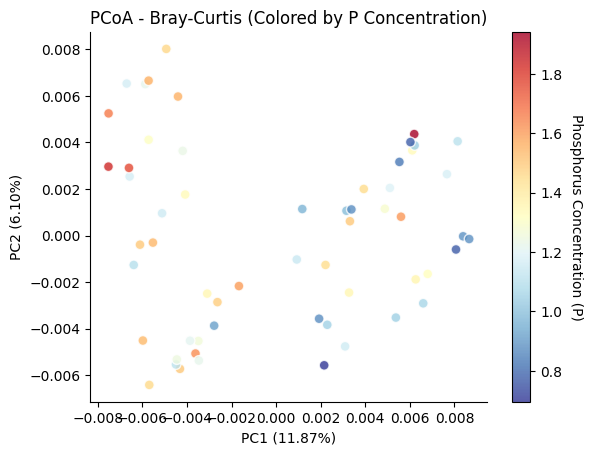

In [15]:
fig, ax = plt.subplots()
sc = ax.scatter(plot_data['PC1'], plot_data['PC2'], 
                 c=plot_data['P'], 
                 cmap='RdYlBu_r', 
                 s=50, edgecolors='white', alpha=0.8)
cbar = plt.colorbar(sc)
cbar.set_label('Phosphorus Concentration (P)', rotation=270, labelpad=15)
pc1_exp = bc_pcoa.proportion_explained[0] * 100
pc2_exp = bc_pcoa.proportion_explained[1] * 100
plt.xlabel(f'PC1 ({pc1_exp:.2f}%)')
plt.ylabel(f'PC2 ({pc2_exp:.2f}%)')
plt.title('PCoA - Bray-Curtis (Colored by P Concentration)')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)